In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt
from skimage.transform import hough_line, hough_line_peaks
import json

from rebar_object_detection import get_bounding_boxes, get_lines, norm_radian

In [2]:
image_path = "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg"
# image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
model_path = "runs/detect/tune/weights/best.pt"

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
vertices = np.array(vertices)

print(vertices)

[[     92.992      59.519]
 [     19.992      107.85]
 [     396.69      116.97]
 [     503.15      279.54]
 [     84.369      109.16]
 [     386.02      67.841]
 [     346.22      173.01]
 [     337.88      115.63]
 [     62.274      237.93]
 [     375.74      24.706]
 [     215.11      39.872]
 [     38.668      364.72]
 [     46.069      12.677]
 [     298.66      525.71]
 [     88.999      84.099]
 [     210.35      362.32]
 [     212.43      140.25]
 [     107.51       531.3]
 [     380.46      44.725]
 [     461.78      411.77]
 [     409.06      173.34]
 [      212.6      170.75]
 [     534.33      173.55]
 [     596.29      173.32]
 [     114.45      468.87]
 [     124.49       363.7]
 [     331.64      67.003]
 [     212.22      203.47]
 [     558.65      462.07]
 [     482.19      205.69]
 [     155.96      38.172]
 [     270.44      20.983]
 [     153.49      60.864]
 [     378.88      413.22]
 [     3.9307      165.99]
 [     371.72      362.37]
 [     25.955      83.623]
 

Detected lines (rho, theta):
Line: rho=470.00, theta=1.55
Line: rho=419.00, theta=1.55
Line: rho=-362.00, theta=-1.57
Line: rho=532.00, theta=1.55
Line: rho=-198.00, theta=-1.55
Line: rho=-279.00, theta=-1.57
Line: rho=324.00, theta=1.55
Line: rho=-166.00, theta=-1.55
Line: rho=-240.00, theta=-1.57
Line: rho=-11.00, theta=-1.54
Line: rho=-136.00, theta=-1.55
Line: rho=-109.00, theta=-1.55
Line: rho=-54.00, theta=-1.54


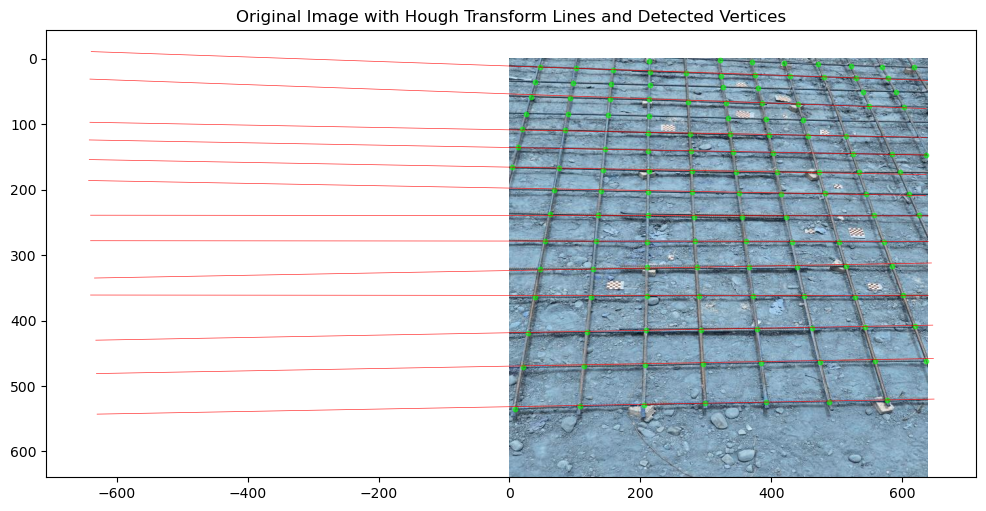

In [3]:
image_path = "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg"

# Load and display the original image
original_image = cv2.imread(image_path)
plt.figure(figsize=(12, 8))
plt.imshow(original_image)

# Get lines data from the model
json_data = get_lines(image_path, model_path, threshold=0)
data = json.loads(json_data)

# Create canvas and draw the lines from get_lines data
height, width = original_image.shape[:2]
canvas = np.zeros((height, width), dtype=np.float32)

# Draw lines on canvas using the get_lines data
for shape in data["shapes"]:
    # if shape["orientation"] == "horizontal":
    if shape["orientation"] == "vertical":
        continue
    points = shape["points"]
    pt1 = (int(points[0][0]), int(points[0][1]))
    pt2 = (int(points[1][0]), int(points[1][1]))
    
    # Draw line on canvas with thickness
    cv2.line(canvas, pt1, pt2, 255, thickness=3)

# Perform Hough Transform
hspace, angles, dists = hough_line(canvas)

# Find peaks
accum, angles_peaks, dists_peaks = hough_line_peaks(hspace, angles, dists, threshold=0.5 * np.max(hspace))

print("Detected lines (rho, theta):")
for rho, theta in zip(dists_peaks, angles_peaks):
    a = np.cos(theta)
    b = np.sin(theta)

    x0 = rho * a
    y0 = rho * b
    
    # Calculate line endpoints
    x1 = int(x0 + width * (-b))
    y1 = int(y0 + height * (a))
    x2 = int(x0 - width * (-b))
    y2 = int(y0 - height * (a))

    # Draw the line on top of the original image
    plt.plot([x1, x2], [y1, y2], '-r', linewidth=0.5, alpha=0.8)
    
    print(f"Line: rho={rho:.2f}, theta={theta:.2f}")

# Also plot the detected vertices
vertices_x = [v[0] for v in vertices]
vertices_y = [v[1] for v in vertices]
plt.scatter(vertices_x, vertices_y, c='lime', s=10, alpha=0.5)

plt.title("Original Image with Hough Transform Lines and Detected Vertices")
plt.show()

In [4]:
angles = []
for theta in angles_peaks:
    angle = norm_radian(theta + np.pi / 2, pi=np.pi)
    angles.append(angle)
angles

[3.12413936106985,
 3.12413936106985,
 0.0,
 3.12413936106985,
 0.01745329251994332,
 0.0,
 3.12413936106985,
 0.01745329251994332,
 0.0,
 0.03490658503988664,
 0.01745329251994332,
 0.01745329251994332,
 0.03490658503988664]

In [5]:
diff = np.ptp(angles)
if diff > np.pi / 2:
    for i in range(len(angles)):
        if angles[i] > np.pi / 2:
            angles[i] = norm_radian(angles[i] + np.pi, pi=np.pi)
angles
min, max = np.min(angles), np.max(angles)
min, max

(-0.017453292519943098, 0.03490658503988664)